In [1]:
import torch
import torch.nn as nn
import importlib
import base_project as bp
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os
import matplotlib.pyplot as plt
import numpy as np
import pseudo_label as pl
from torch.utils.data import Subset

### Setup

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # normalization values for ImageNet (ResNet)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = datasets.OxfordIIITPet(root='./dataset', split='trainval',
                                     download=False, transform=transform)
test_data  = datasets.OxfordIIITPet(root='./dataset', split='test',
                                     download=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2)

In [3]:
FRACTIONS  = [1.0, 0.5, 0.1, 0.01]
NUM_EPOCHS = 20
BASE_LR    = 1e-5
s1_results = {}
s2_results = {}

## Limited data experiment

Based on the previous experiments, Strategy 2: Gradual unfreezing is more suitable for limited data and provides better accuracy compared to Strategy 1: Fine-tuning l layers simultaneously. It allows the model to adapt step by step while preserving the pretrained feature representations. Therefore, the semi-supervised experiments were conducted using Strategy 2: Gradual unfreezing.

### Strategy 2: Gradual unfreezing


------------------------------
S2 | FRACTION: 100%
------------------------------

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.0855, acc: 0.2462 | Test loss: 2.3885, acc: 0.5473
Epoch 2/5 | Train loss: 1.9389, acc: 0.7217 | Test loss: 1.5231, acc: 0.7999
Epoch 3/5 | Train loss: 1.2898, acc: 0.8611 | Test loss: 1.0572, acc: 0.8654
Epoch 4/5 | Train loss: 0.9160, acc: 0.9049 | Test loss: 0.8105, acc: 0.8858
Epoch 5/5 | Train loss: 0.7021, acc: 0.9253 | Test loss: 0.6661, acc: 0.8972

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 0.5383, acc: 0.9353 | Test loss: 0.5401, acc: 0.9043
Epoch 2/5 | Train loss: 0.3990, acc: 0.9533 | Test loss: 0.4787, acc: 0.9030
Epoch 3/5 | Train loss: 0.3028, acc: 0.9682 | Test loss: 0.4301, acc: 0.9046
Epoch 4/5 | Train loss: 0.2456, acc: 0.9788 | Test loss: 0.4013, acc: 0.9095
Epoch 5/5 | Train loss: 0.1952, acc: 0.9842 | Test loss: 0.3789, acc: 0.9101

-- Stage 3 | unfreezing: fc + ['layer4', 'laye

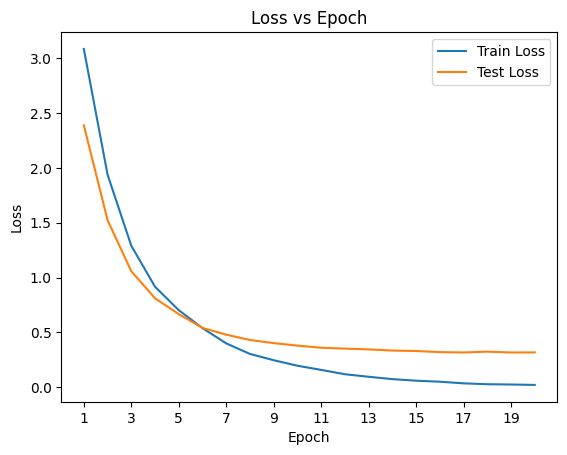

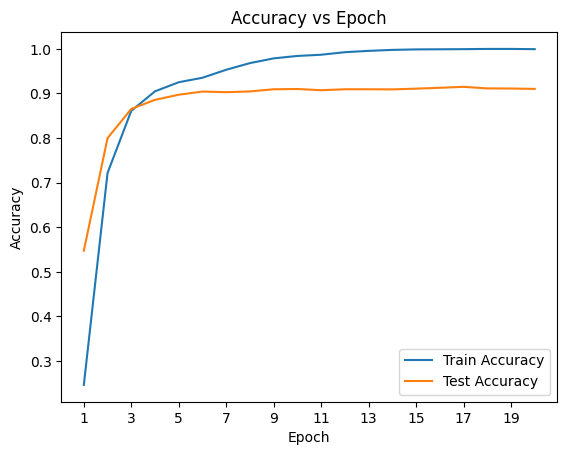

Best acc: 0.9150

------------------------------
S2 | FRACTION: 50%
------------------------------

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.4525, acc: 0.0609 | Test loss: 3.0441, acc: 0.1564
Epoch 2/5 | Train loss: 2.6768, acc: 0.3208 | Test loss: 2.3925, acc: 0.4857
Epoch 3/5 | Train loss: 2.0684, acc: 0.6580 | Test loss: 1.8913, acc: 0.6926
Epoch 4/5 | Train loss: 1.6160, acc: 0.8173 | Test loss: 1.5296, acc: 0.7956
Epoch 5/5 | Train loss: 1.2848, acc: 0.8885 | Test loss: 1.2797, acc: 0.8299

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 1.0396, acc: 0.9076 | Test loss: 1.0467, acc: 0.8517
Epoch 2/5 | Train loss: 0.8241, acc: 0.9315 | Test loss: 0.8837, acc: 0.8599
Epoch 3/5 | Train loss: 0.6572, acc: 0.9516 | Test loss: 0.7850, acc: 0.8686
Epoch 4/5 | Train loss: 0.5409, acc: 0.9549 | Test loss: 0.7103, acc: 0.8744
Epoch 5/5 | Train loss: 0.4386, acc: 0.9690 | Test loss: 0.6460, acc: 0.8782

-- Stage 3 | unfreezing: fc + 

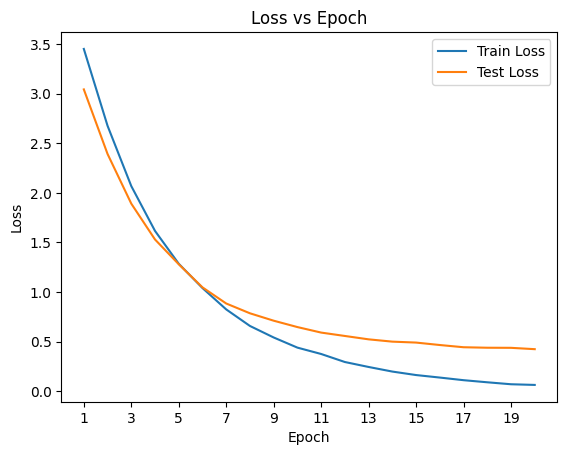

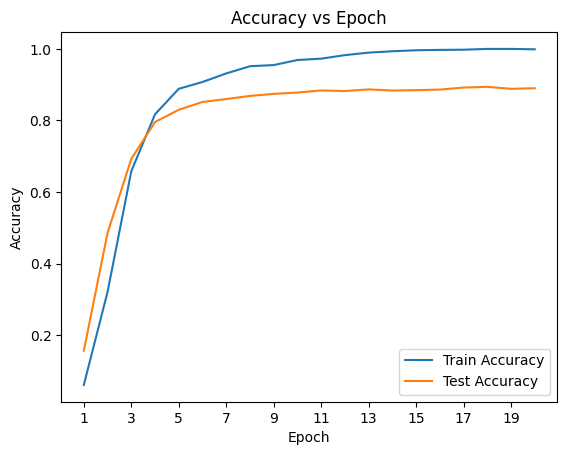

Best acc: 0.8940

------------------------------
S2 | FRACTION: 10%
------------------------------

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.8934, acc: 0.0164 | Test loss: 3.8120, acc: 0.0218
Epoch 2/5 | Train loss: 3.6353, acc: 0.0466 | Test loss: 3.6523, acc: 0.0466
Epoch 3/5 | Train loss: 3.3889, acc: 0.0932 | Test loss: 3.5026, acc: 0.0793
Epoch 4/5 | Train loss: 3.1594, acc: 0.1699 | Test loss: 3.3571, acc: 0.1218
Epoch 5/5 | Train loss: 2.9457, acc: 0.2795 | Test loss: 3.2216, acc: 0.1785

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 2.7491, acc: 0.4082 | Test loss: 3.0837, acc: 0.2358
Epoch 2/5 | Train loss: 2.5235, acc: 0.5233 | Test loss: 2.9524, acc: 0.3014
Epoch 3/5 | Train loss: 2.3319, acc: 0.6411 | Test loss: 2.8204, acc: 0.3614
Epoch 4/5 | Train loss: 2.1579, acc: 0.7260 | Test loss: 2.7029, acc: 0.4151
Epoch 5/5 | Train loss: 1.9963, acc: 0.7863 | Test loss: 2.5913, acc: 0.4606

-- Stage 3 | unfreezing: fc + 

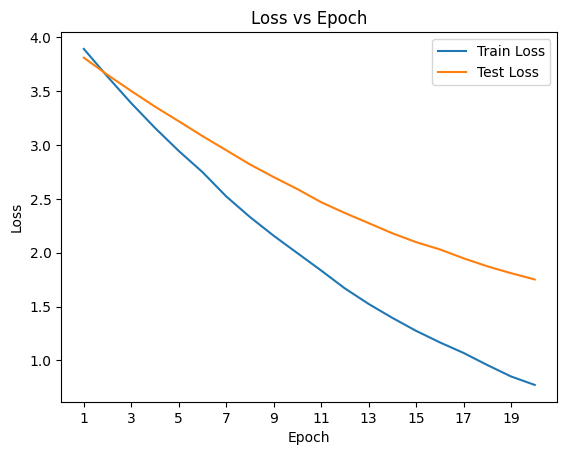

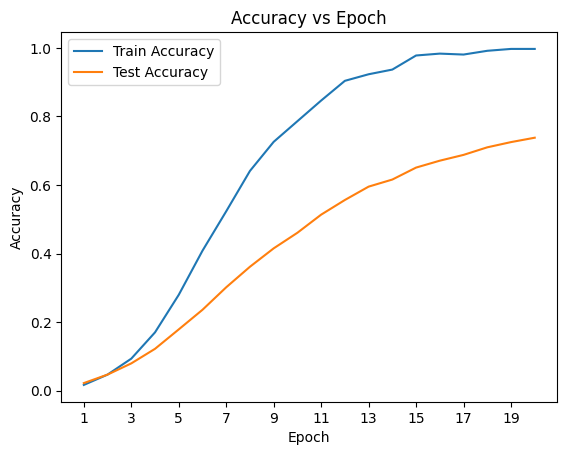

Best acc: 0.7381

------------------------------
S2 | FRACTION: 1%
------------------------------

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/7 | Train loss: 3.8048, acc: 0.0541 | Test loss: 3.8636, acc: 0.0297
Epoch 2/7 | Train loss: 3.8526, acc: 0.0270 | Test loss: 3.8273, acc: 0.0303
Epoch 3/7 | Train loss: 3.5032, acc: 0.1081 | Test loss: 3.7967, acc: 0.0327
Epoch 4/7 | Train loss: 3.6368, acc: 0.0811 | Test loss: 3.7685, acc: 0.0362
Epoch 5/7 | Train loss: 3.4055, acc: 0.1351 | Test loss: 3.7317, acc: 0.0384
Epoch 6/7 | Train loss: 3.1158, acc: 0.1892 | Test loss: 3.6946, acc: 0.0428
Epoch 7/7 | Train loss: 3.0819, acc: 0.1892 | Test loss: 3.6667, acc: 0.0452

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/7 | Train loss: 2.8929, acc: 0.2973 | Test loss: 3.6386, acc: 0.0455
Epoch 2/7 | Train loss: 2.9077, acc: 0.3514 | Test loss: 3.6176, acc: 0.0501
Epoch 3/7 | Train loss: 2.6941, acc: 0.5405 | Test loss: 3.5767, acc: 0.0564
Epoch 4/7 | Train loss: 2.5961, 

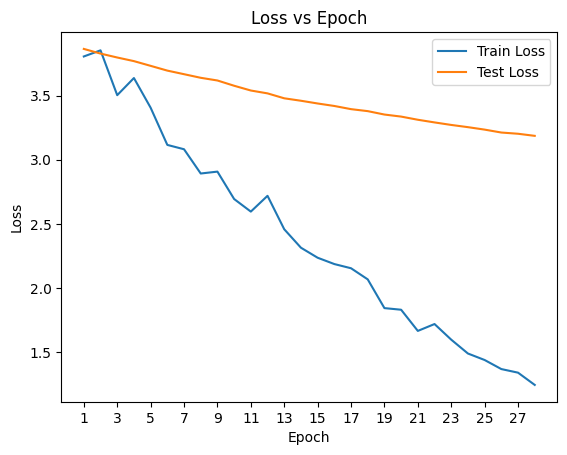

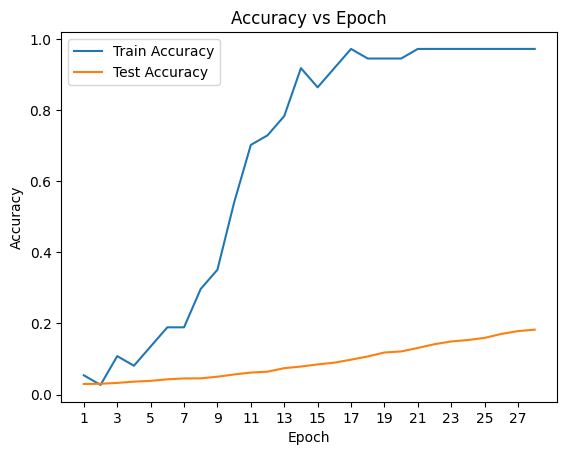

Best acc: 0.1826
S2 done and saved


In [6]:
for frac in FRACTIONS:
    print(f"\n{'-'*30}\nS2 | FRACTION: {frac*100:.0f}%\n{'-'*30}")
    subset      = bp.get_stratified_subset(train_data, frac)
    batch_size  = min(32, max(4, len(subset) // 4))
    num_epochs  = NUM_EPOCHS if frac >= 0.1 else 30
    frac_loader = DataLoader(subset, batch_size=batch_size, shuffle=True, num_workers=2)
    model          = bp.get_model_finetune(num_classes=37).to(device)
    criterion      = nn.CrossEntropyLoss()
    strategy2_best = 0.0
    all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []

    for stage in range(4):
        bp.unfreeze_layers(model, stage + 1)
        optimizer = bp.get_optimizer(model, stage + 1, base_lr=BASE_LR)
        print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
        train_losses, test_losses, train_accs, test_accs, _, best_acc = bp.train_with_history(
            model, frac_loader, test_loader, optimizer, criterion, device, num_epochs=num_epochs//4
        )
        all_train_losses += train_losses
        all_test_losses  += test_losses
        all_train_accs   += train_accs
        all_test_accs    += test_accs
        strategy2_best    = max(strategy2_best, best_acc)

    bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
    s2_results[frac] = strategy2_best
    print(f"Best acc: {strategy2_best:.4f}")

torch.save(s2_results, 'results/semi_supervised/labelled_baseline_s2.pt')
print("S2 done and saved")

### Analysis

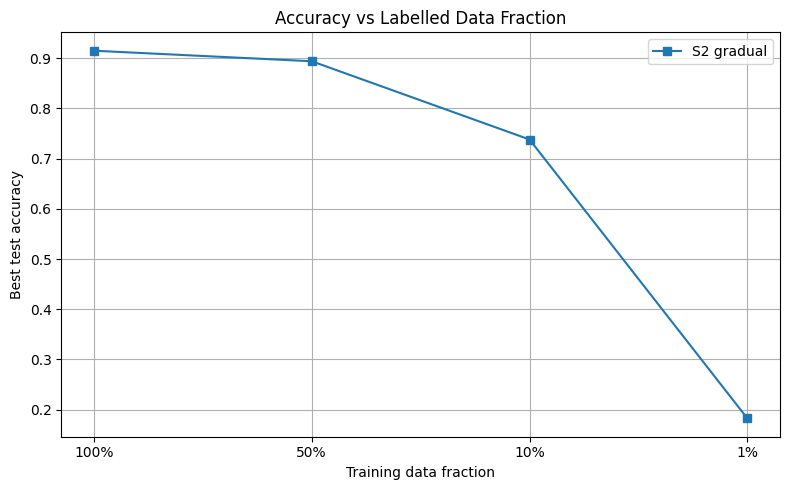

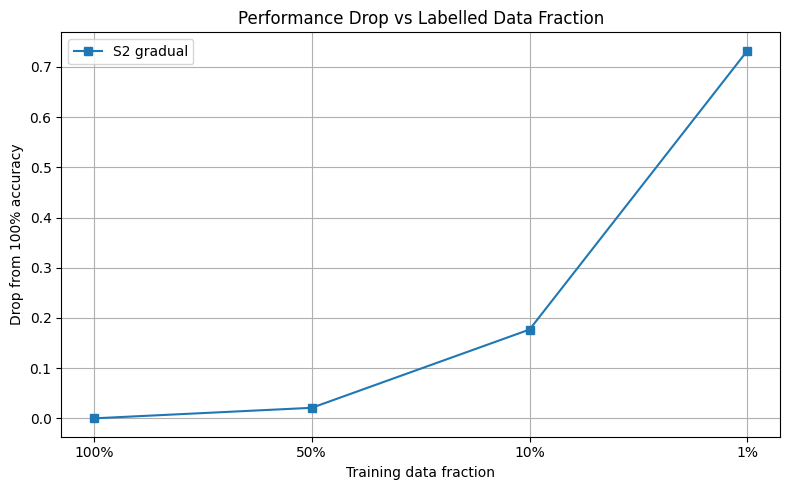

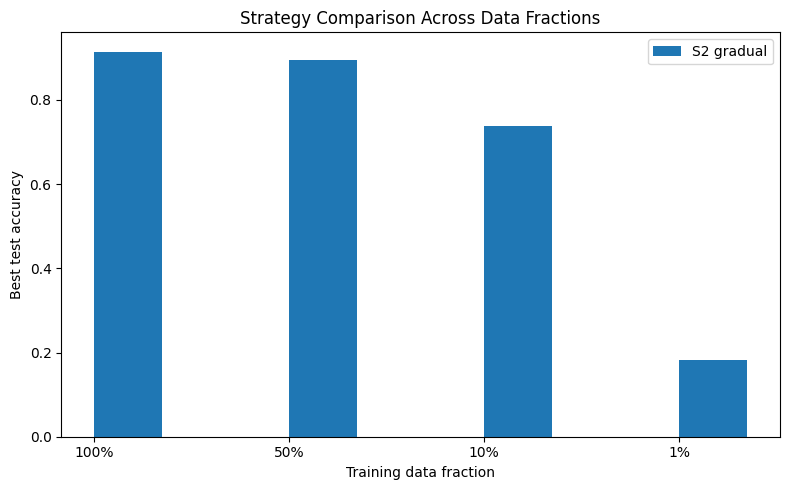

In [15]:
s2_results = torch.load('results/semi_supervised/labelled_baseline_s2.pt')

fractions  = [1.0, 0.5, 0.1, 0.01]
labels     = ['100%', '50%', '10%', '1%']
s1_accs    = [s1_results[f] for f in fractions]
s2_accs    = [s2_results[f] for f in fractions]
best_100   = max(s1_results[1.0], s2_results[1.0])
s2_drops   = [best_100 - s2_results[f] for f in fractions]

# Plot 1 — accuracy vs fraction
plt.figure(figsize=(8, 5))
plt.plot(labels, s2_accs, marker='s', label='S2 gradual')
plt.xlabel('Training data fraction')
plt.ylabel('Best test accuracy')
plt.title('Accuracy vs Labelled Data Fraction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2 — performance drop vs fraction
plt.figure(figsize=(8, 5))
plt.plot(labels, s2_drops, marker='s', label='S2 gradual')
plt.xlabel('Training data fraction')
plt.ylabel('Drop from 100% accuracy')
plt.title('Performance Drop vs Labelled Data Fraction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3 — bar chart comparison
x     = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x + width/2, s2_accs, width, label='S2 gradual')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Training data fraction')
ax.set_ylabel('Best test accuracy')
ax.set_title('Strategy Comparison Across Data Fractions')
ax.legend()
plt.tight_layout()
plt.show()

## Test with unlabelled training data

### Setup

In [6]:
LABELLED_FRACS    = [1.0, 0.5, 0.2, 0.1]
CONFIDENCE_THRESH = 0.75
pseudo_s1_results = {}
pseudo_s2_results = {}

## S2

### S2, 100%


S2 | PSEUDO-LABEL | LABELLED: 100%
Labelled: 3680 | Unlabelled: 0 (full dataset)

-- Step 1: Train on labelled only --

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.1357, acc: 0.2046 | Test loss: 2.4362, acc: 0.5116
Epoch 2/5 | Train loss: 1.9589, acc: 0.7340 | Test loss: 1.5162, acc: 0.8076
Epoch 3/5 | Train loss: 1.2775, acc: 0.8745 | Test loss: 1.0594, acc: 0.8610
Epoch 4/5 | Train loss: 0.9184, acc: 0.9008 | Test loss: 0.8162, acc: 0.8722
Epoch 5/5 | Train loss: 0.7060, acc: 0.9226 | Test loss: 0.6827, acc: 0.8823

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 0.5426, acc: 0.9310 | Test loss: 0.5559, acc: 0.8907
Epoch 2/5 | Train loss: 0.4060, acc: 0.9511 | Test loss: 0.4896, acc: 0.8959
Epoch 3/5 | Train loss: 0.3206, acc: 0.9603 | Test loss: 0.4431, acc: 0.9035
Epoch 4/5 | Train loss: 0.2473, acc: 0.9791 | Test loss: 0.4044, acc: 0.9043
Epoch 5/5 | Train loss: 0.1996, acc: 0.9842 | Test loss: 0.3868, acc: 0.9030

-- Stage 

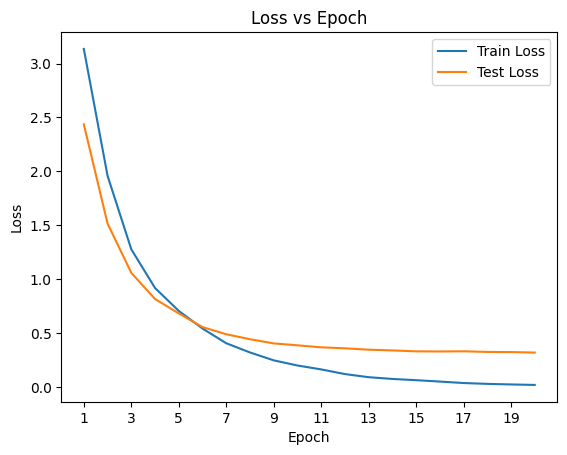

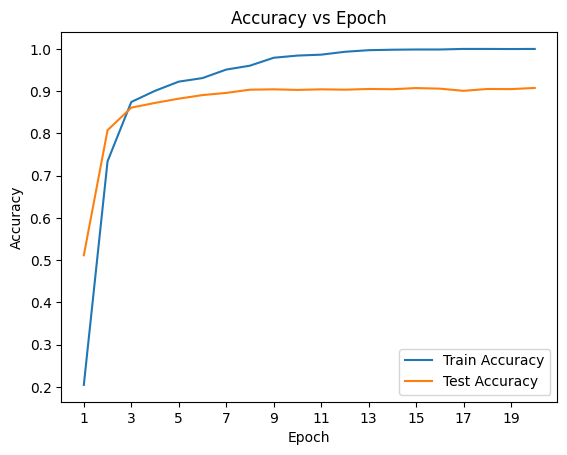

S2 100% acc: 0.9076
S2 100% saved


In [22]:
frac = 1.0
print(f"\n{'='*40}\nS2 | PSEUDO-LABEL | LABELLED: {frac*100:.0f}%\n{'='*40}")

labelled_subset = bp.get_stratified_subset(train_data, frac)
unlabelled_indices = []
unlabelled_subset = Subset(train_data, unlabelled_indices) if unlabelled_indices else None
labelled_loader = DataLoader(labelled_subset, batch_size=32, shuffle=True,  num_workers=2)
print(f"Labelled: {len(labelled_subset)} | Unlabelled: 0 (full dataset)")

print("\n-- Step 1: Train on labelled only --")
model_s2  = bp.get_model_finetune(num_classes=37).to(device)
criterion = nn.CrossEntropyLoss()
s2_labelled_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2, stage + 1)
    optimizer = bp.get_optimizer(model_s2, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2, labelled_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS//4
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs  += test_accs
    s2_labelled_acc = max(s2_labelled_acc, best_acc)
model_s2.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 100% acc: {s2_labelled_acc:.4f}")

pseudo_s2_results[frac] = {'labelled_only': s2_labelled_acc, 'pseudo_label': s2_labelled_acc}
torch.save({'s2': pseudo_s2_results}, 'results/semi_supervised/pseudo_results.pt')
print("S2 100% saved")

### S2, 50%


S2 | PSEUDO-LABEL | LABELLED: 50%
Labelled: 1839 | Unlabelled: 1841

-- Step 1: Train on labelled only --

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.4353, acc: 0.0756 | Test loss: 3.0066, acc: 0.2289
Epoch 2/5 | Train loss: 2.6853, acc: 0.3931 | Test loss: 2.3813, acc: 0.5285
Epoch 3/5 | Train loss: 2.0746, acc: 0.6955 | Test loss: 1.8777, acc: 0.6994
Epoch 4/5 | Train loss: 1.6280, acc: 0.8146 | Test loss: 1.5120, acc: 0.7738
Epoch 5/5 | Train loss: 1.2872, acc: 0.8728 | Test loss: 1.2552, acc: 0.8220

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 1.0240, acc: 0.9070 | Test loss: 1.0212, acc: 0.8487
Epoch 2/5 | Train loss: 0.8091, acc: 0.9320 | Test loss: 0.8767, acc: 0.8602
Epoch 3/5 | Train loss: 0.6649, acc: 0.9451 | Test loss: 0.7639, acc: 0.8703
Epoch 4/5 | Train loss: 0.5386, acc: 0.9636 | Test loss: 0.7002, acc: 0.8738
Epoch 5/5 | Train loss: 0.4415, acc: 0.9657 | Test loss: 0.6415, acc: 0.8757

-- Stage 3 | unfreezin

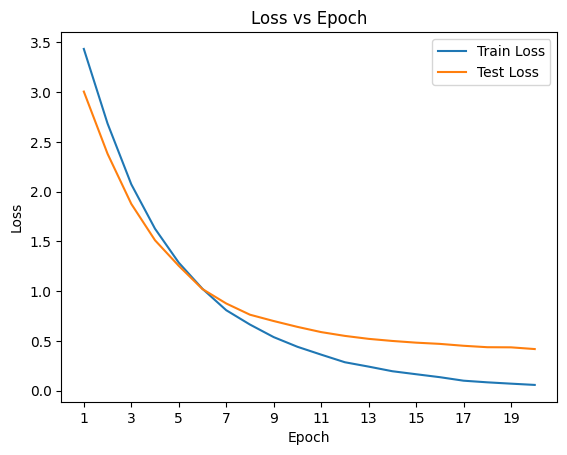

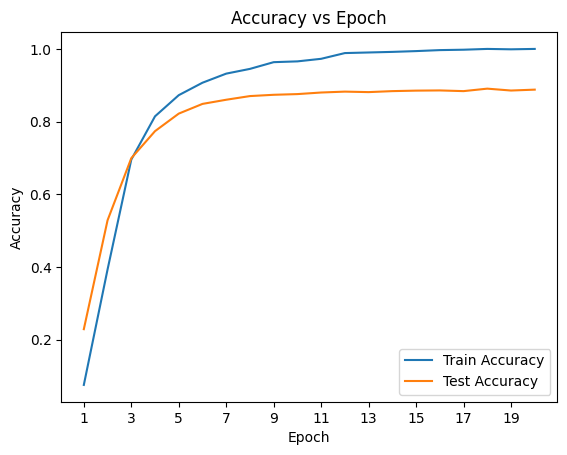

S2 labelled only acc: 0.8907

-- Step 2: Generate pseudo-labels --
Pseudo-labelled: 628 / 1841
Rejected:        1213

-- Step 3: Retrain on labelled + pseudo-labelled --
Combined size: 2467

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.2926, acc: 0.1561 | Test loss: 2.7681, acc: 0.3410
Epoch 2/5 | Train loss: 2.2665, acc: 0.5736 | Test loss: 1.9934, acc: 0.6331
Epoch 3/5 | Train loss: 1.6010, acc: 0.7848 | Test loss: 1.5077, acc: 0.7525
Epoch 4/5 | Train loss: 1.1878, acc: 0.8772 | Test loss: 1.2050, acc: 0.8177
Epoch 5/5 | Train loss: 0.9180, acc: 0.9161 | Test loss: 0.9904, acc: 0.8468

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 0.7298, acc: 0.9307 | Test loss: 0.7909, acc: 0.8700
Epoch 2/5 | Train loss: 0.5420, acc: 0.9481 | Test loss: 0.6873, acc: 0.8760
Epoch 3/5 | Train loss: 0.4330, acc: 0.9660 | Test loss: 0.6030, acc: 0.8874
Epoch 4/5 | Train loss: 0.3519, acc: 0.9732 | Test loss: 0.5569, acc: 0.8880
Epoch 5/5 | Train

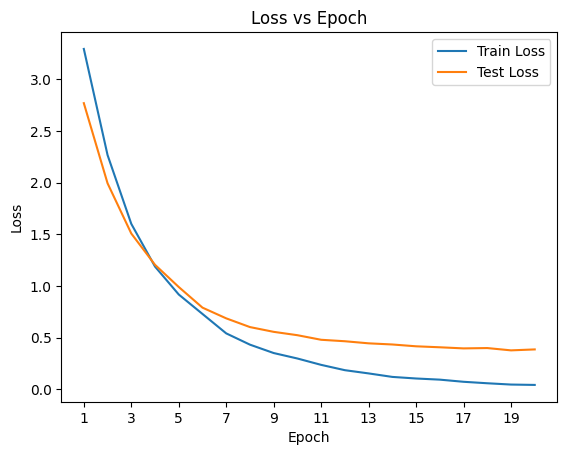

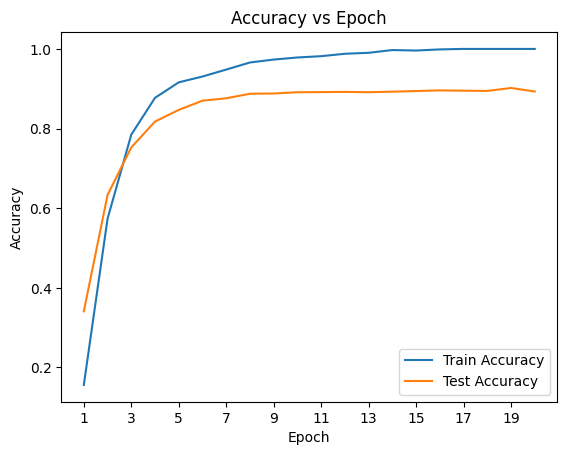

S2 pseudo-label acc: 0.9019
S2 50% saved


In [23]:
frac = 0.5
print(f"\n{'='*40}\nS2 | PSEUDO-LABEL | LABELLED: {frac*100:.0f}%\n{'='*40}")

labelled_subset = bp.get_stratified_subset(train_data, frac)
labelled_indices = set(labelled_subset.indices)
unlabelled_indices = list(set(range(len(train_data))) - labelled_indices)
unlabelled_subset = Subset(train_data, unlabelled_indices)
labelled_loader = DataLoader(labelled_subset,   batch_size=32, shuffle=True,  num_workers=2)
unlabelled_loader = DataLoader(unlabelled_subset, batch_size=32, shuffle=False, num_workers=2)
print(f"Labelled: {len(labelled_subset)} | Unlabelled: {len(unlabelled_subset)}")

print("\n-- Step 1: Train on labelled only --")
model_s2  = bp.get_model_finetune(num_classes=37).to(device)
criterion = nn.CrossEntropyLoss()
s2_labelled_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2, stage + 1)
    optimizer = bp.get_optimizer(model_s2, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2, labelled_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS//4
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs  += test_accs
    s2_labelled_acc   = max(s2_labelled_acc, best_acc)
model_s2.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 labelled only acc: {s2_labelled_acc:.4f}")

print("\n-- Step 2: Generate pseudo-labels --")
pseudo_indices, pseudo_labels = pl.generate_pseudo_labels(
    model_s2, unlabelled_loader, device, confidence_threshold=CONFIDENCE_THRESH
)
print(f"Pseudo-labelled: {len(pseudo_indices)} / {len(unlabelled_subset)}")
print(f"Rejected:        {len(unlabelled_subset) - len(pseudo_indices)}")

print("\n-- Step 3: Retrain on labelled + pseudo-labelled --")
combined_dataset = pl.PseudoLabelDataset(labelled_subset, unlabelled_subset, pseudo_indices, pseudo_labels)
combined_loader  = DataLoader(combined_dataset, batch_size=32, shuffle=True, num_workers=2)
print(f"Combined size: {len(combined_dataset)}")
model_s2_pl = bp.get_model_finetune(num_classes=37).to(device)
criterion   = nn.CrossEntropyLoss()
s2_pseudo_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2_pl, stage + 1)
    optimizer = bp.get_optimizer(model_s2_pl, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2_pl, combined_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS//4
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs += test_accs
    s2_pseudo_acc     = max(s2_pseudo_acc, best_acc)
model_s2_pl.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 pseudo-label acc: {s2_pseudo_acc:.4f}")

pseudo_s2_results[frac] = {'labelled_only': s2_labelled_acc, 'pseudo_label': s2_pseudo_acc}
torch.save({'s2': pseudo_s2_results}, 'results/semi_supervised/pseudo_results.pt')
print("S2 50% saved")

### S2, 20%


S2 | PSEUDO-LABEL | LABELLED: 20%
Labelled: 734 | Unlabelled: 2946

-- Step 1: Train on labelled only --

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.6942, acc: 0.0300 | Test loss: 3.5105, acc: 0.0578
Epoch 2/5 | Train loss: 3.2970, acc: 0.1076 | Test loss: 3.2243, acc: 0.1311
Epoch 3/5 | Train loss: 2.9451, acc: 0.2371 | Test loss: 2.9586, acc: 0.2330
Epoch 4/5 | Train loss: 2.6219, acc: 0.4278 | Test loss: 2.7115, acc: 0.3701
Epoch 5/5 | Train loss: 2.3298, acc: 0.6104 | Test loss: 2.4858, acc: 0.4895

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 2.0925, acc: 0.7234 | Test loss: 2.2653, acc: 0.5658
Epoch 2/5 | Train loss: 1.8258, acc: 0.8174 | Test loss: 2.0656, acc: 0.6410
Epoch 3/5 | Train loss: 1.5804, acc: 0.8924 | Test loss: 1.8947, acc: 0.6936
Epoch 4/5 | Train loss: 1.3949, acc: 0.9223 | Test loss: 1.7455, acc: 0.7315
Epoch 5/5 | Train loss: 1.2169, acc: 0.9482 | Test loss: 1.6172, acc: 0.7542

-- Stage 3 | unfreezing

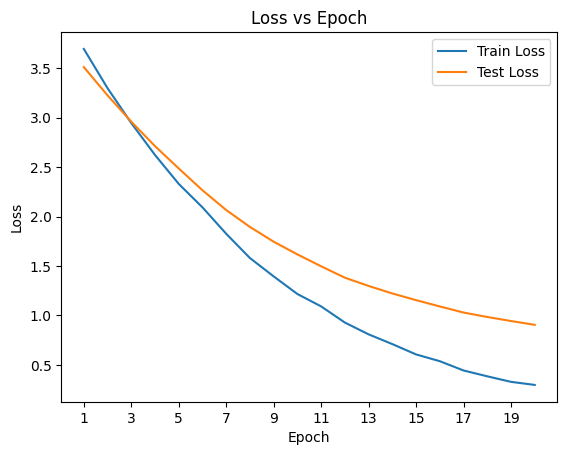

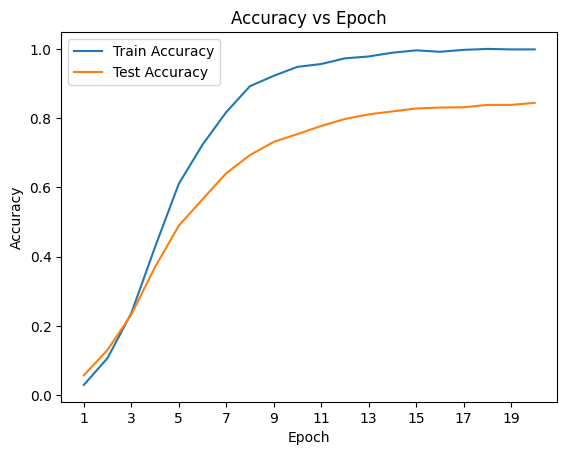

S2 labelled only acc: 0.8444

-- Step 2: Generate pseudo-labels --
Pseudo-labelled: 627 / 2946
Rejected:        2319

-- Step 3: Retrain on labelled + pseudo-labelled --
Combined size: 1361

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.4347, acc: 0.1352 | Test loss: 3.1851, acc: 0.2240
Epoch 2/5 | Train loss: 2.6440, acc: 0.4475 | Test loss: 2.6537, acc: 0.4233
Epoch 3/5 | Train loss: 2.0306, acc: 0.6613 | Test loss: 2.2334, acc: 0.5372
Epoch 4/5 | Train loss: 1.5757, acc: 0.7722 | Test loss: 1.9327, acc: 0.6285
Epoch 5/5 | Train loss: 1.2752, acc: 0.8494 | Test loss: 1.6860, acc: 0.6797

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 1.0418, acc: 0.8832 | Test loss: 1.4330, acc: 0.7383
Epoch 2/5 | Train loss: 0.8041, acc: 0.9206 | Test loss: 1.2545, acc: 0.7760
Epoch 3/5 | Train loss: 0.6384, acc: 0.9493 | Test loss: 1.1041, acc: 0.7997
Epoch 4/5 | Train loss: 0.5258, acc: 0.9640 | Test loss: 1.0004, acc: 0.8193
Epoch 5/5 | Train

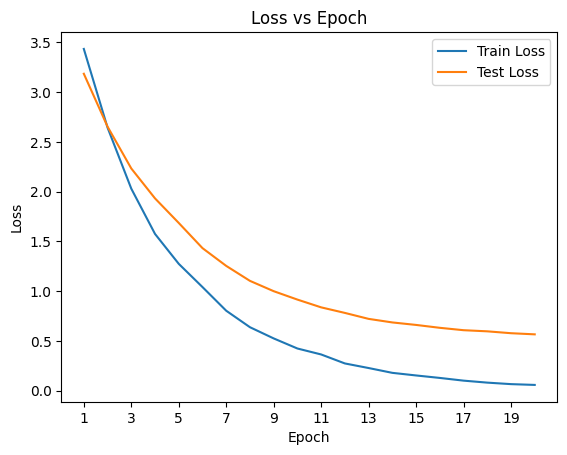

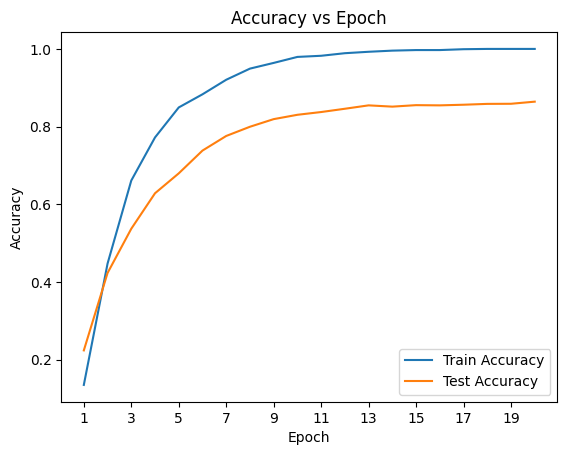

S2 pseudo-label acc: 0.8643
S2 20% saved


In [8]:
frac = 0.2
CONFIDENCE_THRESH_20 = 0.75
print(f"\n{'='*40}\nS2 | PSEUDO-LABEL | LABELLED: {frac*100:.0f}%\n{'='*40}")

labelled_subset = bp.get_stratified_subset(train_data, frac)
labelled_indices  = set(labelled_subset.indices)
unlabelled_indices = list(set(range(len(train_data))) - labelled_indices)
unlabelled_subset = Subset(train_data, unlabelled_indices)
labelled_loader = DataLoader(labelled_subset,   batch_size=32, shuffle=True,  num_workers=2)
unlabelled_loader = DataLoader(unlabelled_subset, batch_size=32, shuffle=False, num_workers=2)
print(f"Labelled: {len(labelled_subset)} | Unlabelled: {len(unlabelled_subset)}")

print("\n-- Step 1: Train on labelled only --")
model_s2  = bp.get_model_finetune(num_classes=37).to(device)
criterion = nn.CrossEntropyLoss()
s2_labelled_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2, stage + 1)
    optimizer = bp.get_optimizer(model_s2, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2, labelled_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS//4
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs += test_accs
    s2_labelled_acc = max(s2_labelled_acc, best_acc)
model_s2.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 labelled only acc: {s2_labelled_acc:.4f}")

print("\n-- Step 2: Generate pseudo-labels --")
pseudo_indices, pseudo_labels = pl.generate_pseudo_labels(
    model_s2, unlabelled_loader, device, confidence_threshold=CONFIDENCE_THRESH_20
)
print(f"Pseudo-labelled: {len(pseudo_indices)} / {len(unlabelled_subset)}")
print(f"Rejected:        {len(unlabelled_subset) - len(pseudo_indices)}")

print("\n-- Step 3: Retrain on labelled + pseudo-labelled --")
combined_dataset = pl.PseudoLabelDataset(labelled_subset, unlabelled_subset, pseudo_indices, pseudo_labels)
combined_loader  = DataLoader(combined_dataset, batch_size=32, shuffle=True, num_workers=2)
print(f"Combined size: {len(combined_dataset)}")
model_s2_pl = bp.get_model_finetune(num_classes=37).to(device)
criterion   = nn.CrossEntropyLoss()
s2_pseudo_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2_pl, stage + 1)
    optimizer = bp.get_optimizer(model_s2_pl, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2_pl, combined_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS//4
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs += test_accs
    s2_pseudo_acc = max(s2_pseudo_acc, best_acc)
model_s2_pl.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 pseudo-label acc: {s2_pseudo_acc:.4f}")

pseudo_s2_results[frac] = {'labelled_only': s2_labelled_acc, 'pseudo_label': s2_pseudo_acc}
torch.save({'s2': pseudo_s2_results}, 'results/semi_supervised/pseudo_results.pt')
print("S2 20% saved")

### S2, 10%


S2 | PSEUDO-LABEL | LABELLED: 10%
Labelled: 365 | Unlabelled: 3315

-- Step 1: Train on labelled only --

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.8391, acc: 0.0384 | Test loss: 3.7348, acc: 0.0387
Epoch 2/5 | Train loss: 3.5601, acc: 0.0767 | Test loss: 3.5792, acc: 0.0641
Epoch 3/5 | Train loss: 3.3251, acc: 0.0904 | Test loss: 3.4329, acc: 0.0965
Epoch 4/5 | Train loss: 3.0946, acc: 0.1507 | Test loss: 3.2943, acc: 0.1267
Epoch 5/5 | Train loss: 2.8643, acc: 0.2493 | Test loss: 3.1588, acc: 0.1603

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 2.7134, acc: 0.3397 | Test loss: 3.0190, acc: 0.2044
Epoch 2/5 | Train loss: 2.4840, acc: 0.4795 | Test loss: 2.8867, acc: 0.2679
Epoch 3/5 | Train loss: 2.2640, acc: 0.6274 | Test loss: 2.7663, acc: 0.3309
Epoch 4/5 | Train loss: 2.0987, acc: 0.7205 | Test loss: 2.6463, acc: 0.3966
Epoch 5/5 | Train loss: 1.9592, acc: 0.8027 | Test loss: 2.5449, acc: 0.4519

-- Stage 3 | unfreezing

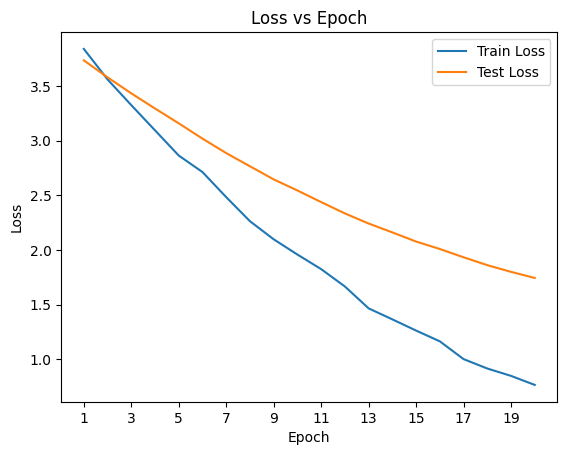

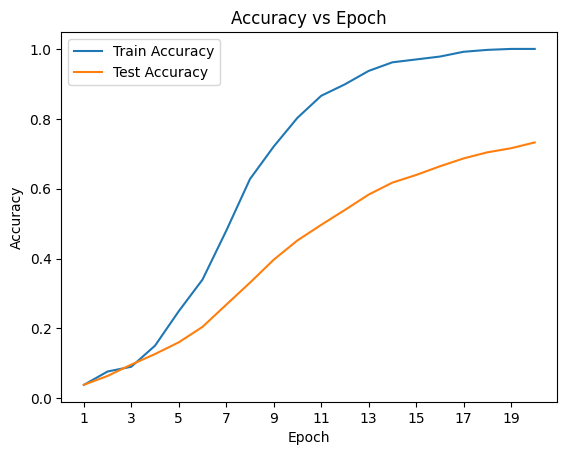

S2 labelled only acc: 0.7324

-- Step 2: Generate pseudo-labels --
Pseudo-labelled: 37 / 3315
Rejected:        3278

-- Step 3: Retrain on labelled + pseudo-labelled --
Combined size: 402

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/5 | Train loss: 3.7908, acc: 0.0124 | Test loss: 3.6646, acc: 0.0324
Epoch 2/5 | Train loss: 3.4881, acc: 0.0522 | Test loss: 3.4898, acc: 0.0619
Epoch 3/5 | Train loss: 3.2153, acc: 0.1219 | Test loss: 3.3234, acc: 0.1096
Epoch 4/5 | Train loss: 2.9664, acc: 0.3060 | Test loss: 3.1720, acc: 0.1780
Epoch 5/5 | Train loss: 2.7175, acc: 0.4353 | Test loss: 3.0196, acc: 0.2513

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --
Epoch 1/5 | Train loss: 2.5064, acc: 0.5771 | Test loss: 2.8699, acc: 0.3282
Epoch 2/5 | Train loss: 2.2573, acc: 0.6965 | Test loss: 2.7334, acc: 0.3898
Epoch 3/5 | Train loss: 2.0686, acc: 0.7786 | Test loss: 2.6005, acc: 0.4464
Epoch 4/5 | Train loss: 1.8655, acc: 0.8507 | Test loss: 2.4817, acc: 0.4963
Epoch 5/5 | Train l

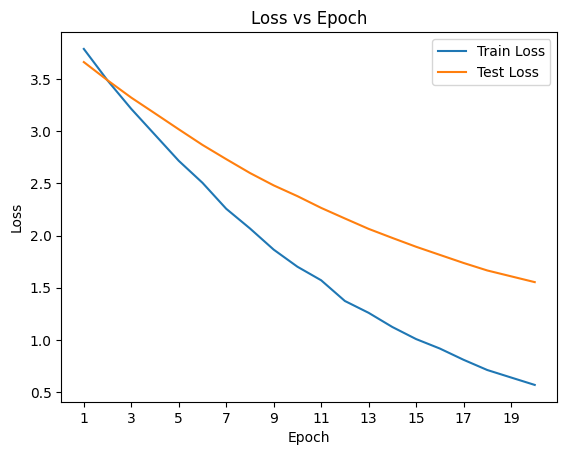

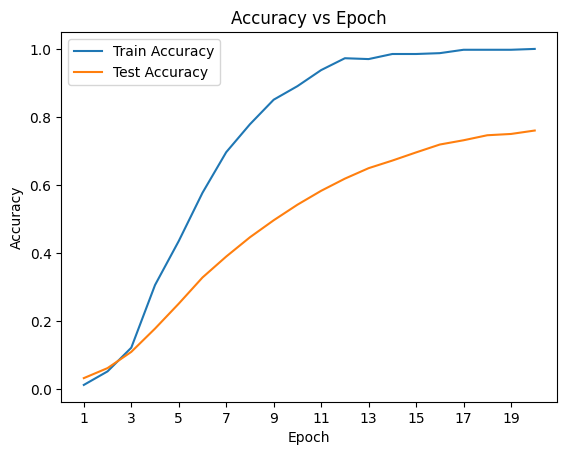

S2 pseudo-label acc: 0.7602
S2 10% saved


In [10]:
frac = 0.1
CONFIDENCE_THRESH_10 = 0.65
print(f"\n{'='*40}\nS2 | PSEUDO-LABEL | LABELLED: {frac*100:.0f}%\n{'='*40}")

labelled_subset = bp.get_stratified_subset(train_data, frac)
labelled_indices = set(labelled_subset.indices)
unlabelled_indices = list(set(range(len(train_data))) - labelled_indices)
unlabelled_subset = Subset(train_data, unlabelled_indices)
labelled_loader = DataLoader(labelled_subset,   batch_size=32, shuffle=True,  num_workers=2)
unlabelled_loader = DataLoader(unlabelled_subset, batch_size=32, shuffle=False, num_workers=2)
print(f"Labelled: {len(labelled_subset)} | Unlabelled: {len(unlabelled_subset)}")

print("\n-- Step 1: Train on labelled only --")
model_s2  = bp.get_model_finetune(num_classes=37).to(device)
criterion = nn.CrossEntropyLoss()
s2_labelled_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2, stage + 1)
    optimizer = bp.get_optimizer(model_s2, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2, labelled_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS//4
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs += test_accs
    s2_labelled_acc = max(s2_labelled_acc, best_acc)
model_s2.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 labelled only acc: {s2_labelled_acc:.4f}")

print("\n-- Step 2: Generate pseudo-labels --")
pseudo_indices, pseudo_labels = pl.generate_pseudo_labels(
    model_s2, unlabelled_loader, device, confidence_threshold=CONFIDENCE_THRESH_10
)
print(f"Pseudo-labelled: {len(pseudo_indices)} / {len(unlabelled_subset)}")
print(f"Rejected:        {len(unlabelled_subset) - len(pseudo_indices)}")

print("\n-- Step 3: Retrain on labelled + pseudo-labelled --")
combined_dataset = pl.PseudoLabelDataset(labelled_subset, unlabelled_subset, pseudo_indices, pseudo_labels)
combined_loader  = DataLoader(combined_dataset, batch_size=32, shuffle=True, num_workers=2)
print(f"Combined size: {len(combined_dataset)}")
model_s2_pl = bp.get_model_finetune(num_classes=37).to(device)
criterion   = nn.CrossEntropyLoss()
s2_pseudo_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2_pl, stage + 1)
    optimizer = bp.get_optimizer(model_s2_pl, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2_pl, combined_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS//4
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs += test_accs
    s2_pseudo_acc = max(s2_pseudo_acc, best_acc)
model_s2_pl.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 pseudo-label acc: {s2_pseudo_acc:.4f}")

pseudo_s2_results[frac] = {'labelled_only': s2_labelled_acc, 'pseudo_label': s2_pseudo_acc}
torch.save({'s2': pseudo_s2_results}, 'results/semi_supervised/pseudo_results.pt')
print("S2 10% saved")

### S2, 1%


S2 | PSEUDO-LABEL | LABELLED: 1%
Labelled: 37 | Unlabelled: 3643 | Batch size: 9

-- Step 1: Train on labelled only --

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/10 | Train loss: 3.6481, acc: 0.0000 | Test loss: 3.8411, acc: 0.0144
Epoch 2/10 | Train loss: 3.7579, acc: 0.0270 | Test loss: 3.7908, acc: 0.0180
Epoch 3/10 | Train loss: 3.5697, acc: 0.0811 | Test loss: 3.7506, acc: 0.0207
Epoch 4/10 | Train loss: 3.2993, acc: 0.1081 | Test loss: 3.7141, acc: 0.0243
Epoch 5/10 | Train loss: 3.3292, acc: 0.2432 | Test loss: 3.6790, acc: 0.0248
Epoch 6/10 | Train loss: 3.2056, acc: 0.2703 | Test loss: 3.6460, acc: 0.0281
Epoch 7/10 | Train loss: 2.8566, acc: 0.3243 | Test loss: 3.6256, acc: 0.0333
Epoch 8/10 | Train loss: 2.9364, acc: 0.3784 | Test loss: 3.6035, acc: 0.0324
Epoch 9/10 | Train loss: 2.9336, acc: 0.4324 | Test loss: 3.5718, acc: 0.0403
Epoch 10/10 | Train loss: 2.7036, acc: 0.5676 | Test loss: 3.5509, acc: 0.0428

-- Stage 2 | unfreezing: fc + ['layer4', 'layer3'] --

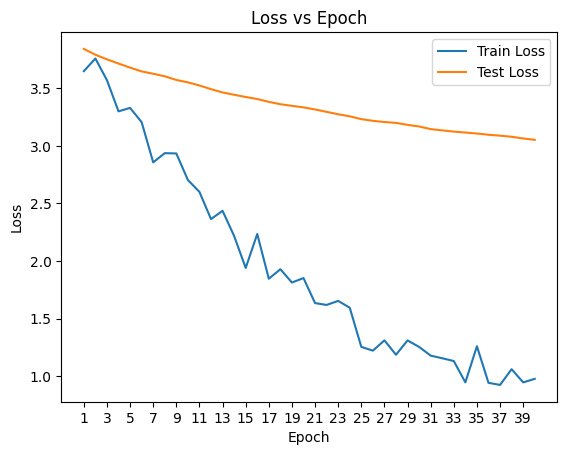

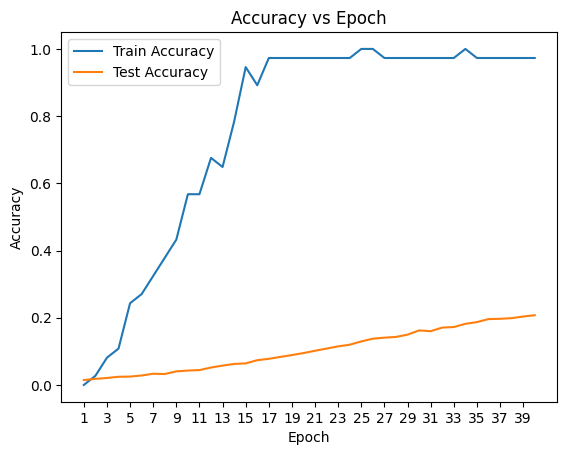

S2 labelled only acc: 0.2074

-- Step 2: Generate pseudo-labels --
Pseudo-labelled: 3 / 3643
Rejected:        3640

-- Step 3: Retrain on labelled + pseudo-labelled --
Combined size: 40 | Batch size: 10

-- Stage 1 | unfreezing: fc + ['layer4'] --
Epoch 1/10 | Train loss: 4.0812, acc: 0.0250 | Test loss: 3.9576, acc: 0.0166
Epoch 2/10 | Train loss: 3.8136, acc: 0.0500 | Test loss: 3.9167, acc: 0.0188
Epoch 3/10 | Train loss: 3.6610, acc: 0.0500 | Test loss: 3.8787, acc: 0.0204
Epoch 4/10 | Train loss: 3.4869, acc: 0.0750 | Test loss: 3.8432, acc: 0.0232
Epoch 5/10 | Train loss: 3.2808, acc: 0.0750 | Test loss: 3.8105, acc: 0.0253
Epoch 6/10 | Train loss: 3.1291, acc: 0.0750 | Test loss: 3.7774, acc: 0.0275
Epoch 7/10 | Train loss: 2.9672, acc: 0.1500 | Test loss: 3.7451, acc: 0.0294
Epoch 8/10 | Train loss: 2.7936, acc: 0.3000 | Test loss: 3.7124, acc: 0.0303
Epoch 9/10 | Train loss: 2.6737, acc: 0.4000 | Test loss: 3.6830, acc: 0.0308
Epoch 10/10 | Train loss: 2.5343, acc: 0.5250 | Te

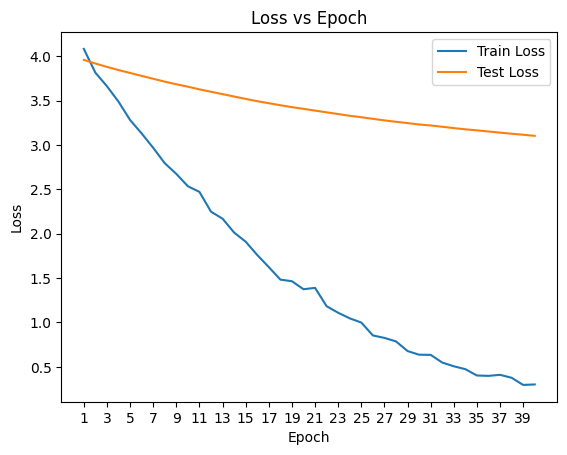

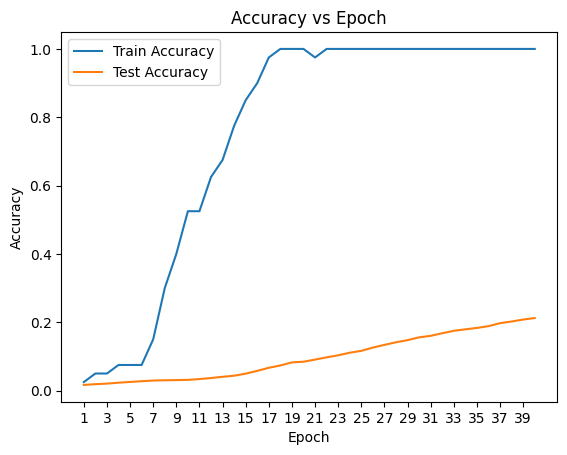

S2 pseudo-label acc: 0.2123
S2 1% saved


In [15]:
frac = 0.01
CONFIDENCE_THRESH_1 = 0.5
NUM_EPOCHS_1 = 10
BASE_LR_1 = 1e-4 

print(f"\n{'='*40}\nS2 | PSEUDO-LABEL | LABELLED: {frac*100:.0f}%\n{'='*40}")
labelled_subset = bp.get_stratified_subset(train_data, frac)
labelled_indices = set(labelled_subset.indices)
unlabelled_indices = list(set(range(len(train_data))) - labelled_indices)
unlabelled_subset = Subset(train_data, unlabelled_indices)
batch_size = min(32, max(4, len(labelled_subset) // 4))
labelled_loader = DataLoader(labelled_subset,   batch_size=batch_size, shuffle=True,  num_workers=2)
unlabelled_loader = DataLoader(unlabelled_subset, batch_size=32,         shuffle=False, num_workers=2)
print(f"Labelled: {len(labelled_subset)} | Unlabelled: {len(unlabelled_subset)} | Batch size: {batch_size}")

print("\n-- Step 1: Train on labelled only --")
model_s2  = bp.get_model_finetune(num_classes=37).to(device)
criterion = nn.CrossEntropyLoss()
s2_labelled_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2, stage + 1)
    optimizer = bp.get_optimizer(model_s2, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2, labelled_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS_1
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs += test_accs
    s2_labelled_acc = max(s2_labelled_acc, best_acc)
model_s2.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 labelled only acc: {s2_labelled_acc:.4f}")

print("\n-- Step 2: Generate pseudo-labels --")
pseudo_indices, pseudo_labels = pl.generate_pseudo_labels(
    model_s2, unlabelled_loader, device, confidence_threshold=CONFIDENCE_THRESH_1
)
print(f"Pseudo-labelled: {len(pseudo_indices)} / {len(unlabelled_subset)}")
print(f"Rejected:        {len(unlabelled_subset) - len(pseudo_indices)}")

print("\n-- Step 3: Retrain on labelled + pseudo-labelled --")
combined_dataset = pl.PseudoLabelDataset(labelled_subset, unlabelled_subset, pseudo_indices, pseudo_labels)
combined_batch = min(32, max(4, len(combined_dataset) // 4))
combined_loader = DataLoader(combined_dataset, batch_size=combined_batch, shuffle=True, num_workers=2)
print(f"Combined size: {len(combined_dataset)} | Batch size: {combined_batch}")
model_s2_pl = bp.get_model_finetune(num_classes=37).to(device)
criterion   = nn.CrossEntropyLoss()
s2_pseudo_acc = 0.0
all_train_losses, all_test_losses, all_train_accs, all_test_accs = [], [], [], []
for stage in range(4):
    bp.unfreeze_layers(model_s2_pl, stage + 1)
    optimizer = bp.get_optimizer(model_s2_pl, stage + 1, base_lr=BASE_LR)
    print(f"\n-- Stage {stage+1} | unfreezing: fc + {bp.RESNET34_LAYER_GROUPS[:stage+1]} --")
    train_losses, test_losses, train_accs, test_accs, best_model, best_acc = bp.train_with_history(
        model_s2_pl, combined_loader, test_loader, optimizer, criterion, device, num_epochs=NUM_EPOCHS_1
    )
    all_train_losses += train_losses
    all_test_losses += test_losses
    all_train_accs += train_accs
    all_test_accs += test_accs
    s2_pseudo_acc = max(s2_pseudo_acc, best_acc)
model_s2_pl.load_state_dict(best_model)
bp.plot_training_curves(all_train_losses, all_test_losses, all_train_accs, all_test_accs)
print(f"S2 pseudo-label acc: {s2_pseudo_acc:.4f}")

pseudo_s2_results[frac] = {'labelled_only': s2_labelled_acc, 'pseudo_label': s2_pseudo_acc}
torch.save({'s2': pseudo_s2_results}, 'results/semi_supervised/pseudo_results.pt')
print("S2 1% saved")

### Analysis


****** S2 PSEUDO-LABELLING SUMMARY ******
Fraction     Labelled only        + Pseudo   Improvement   Gap closed
-------------------------------------------------------------------
   100%            0.9139          0.9139        0.0000         0.0%
    50%            0.8907          0.9019        0.0112        48.3%
    20%            0.8444          0.8643        0.0199        28.6%
    10%            0.7324          0.7602        0.0278        15.3%
     1%            0.2074          0.2123        0.0049         0.7%

S2 full dataset (100%) baseline: 0.9139


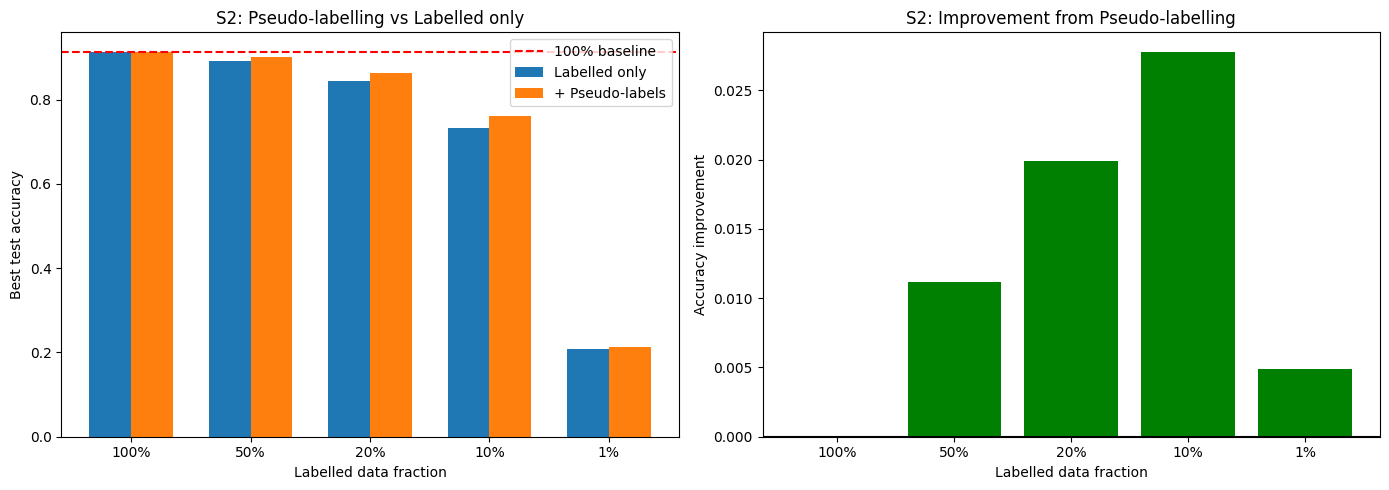

In [22]:
data = torch.load('results/semi_supervised/pseudo_results.pt')
pseudo_s2_results = data['s2']

fracs    = [1.0, 0.5, 0.2, 0.1, 0.01]
labels   = ['100%', '50%', '20%', '10%', '1%']
s2_full  = pseudo_s2_results[1.0]['labelled_only']

# summary table
print("\n****** S2 PSEUDO-LABELLING SUMMARY ******")
print(f"{'Fraction':<10} {'Labelled only':>15} {'+ Pseudo':>15} {'Improvement':>13} {'Gap closed':>12}")
print("-" * 67)
for frac in fracs:
    labelled_acc = pseudo_s2_results[frac]['labelled_only']
    pseudo_acc   = pseudo_s2_results[frac]['pseudo_label']
    improvement  = pseudo_acc - labelled_acc
    gap          = s2_full - labelled_acc
    gap_closed   = (improvement / gap * 100) if gap > 0 else 0
    print(f"{frac*100:>6.0f}%   {labelled_acc:>15.4f} {pseudo_acc:>15.4f} {improvement:>13.4f} {gap_closed:>11.1f}%")
print(f"\nS2 full dataset (100%) baseline: {s2_full:.4f}")

# plot
import matplotlib.pyplot as plt
import numpy as np

x     = np.arange(len(labels))
width = 0.35

labelled_accs = [pseudo_s2_results[f]['labelled_only'] for f in fracs]
pseudo_accs   = [pseudo_s2_results[f]['pseudo_label']  for f in fracs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart
axes[0].bar(x - width/2, labelled_accs, width, label='Labelled only')
axes[0].bar(x + width/2, pseudo_accs,   width, label='+ Pseudo-labels')
axes[0].axhline(y=s2_full, color='red', linestyle='--', label='100% baseline')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Labelled data fraction')
axes[0].set_ylabel('Best test accuracy')
axes[0].set_title('S2: Pseudo-labelling vs Labelled only')
axes[0].legend()

# improvement chart
improvements = [pseudo_s2_results[f]['pseudo_label'] - pseudo_s2_results[f]['labelled_only'] for f in fracs]
axes[1].bar(labels, improvements, color='green')
axes[1].axhline(y=0, color='black', linestyle='-')
axes[1].set_xlabel('Labelled data fraction')
axes[1].set_ylabel('Accuracy improvement')
axes[1].set_title('S2: Improvement from Pseudo-labelling')

plt.tight_layout()
plt.show()

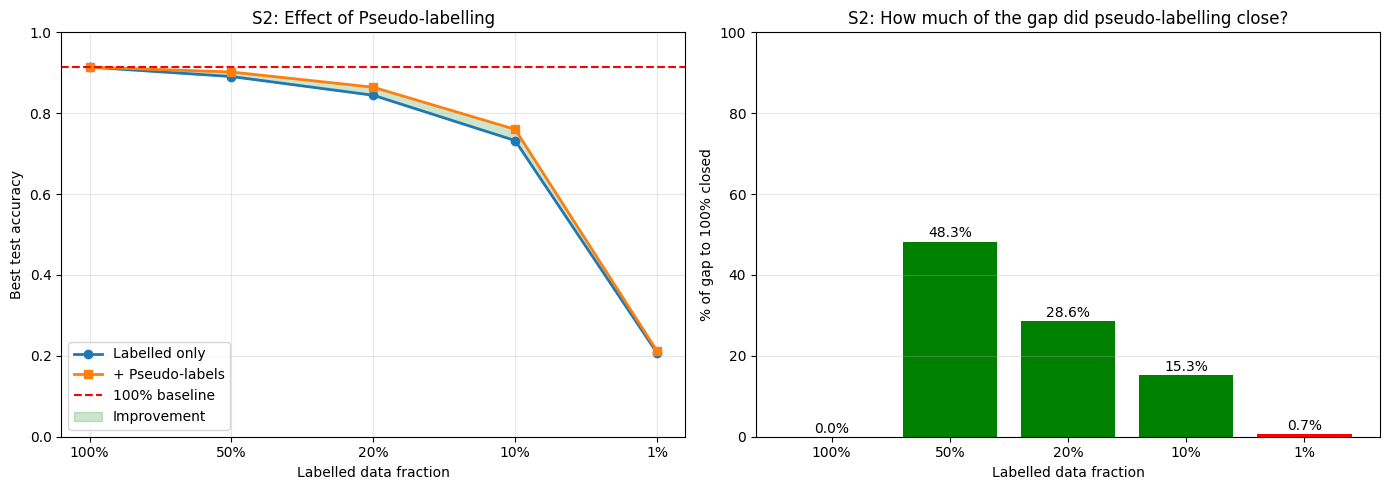

In [24]:
fracs    = [1.0, 0.5, 0.2, 0.1, 0.01]
labels   = ['100%', '50%', '20%', '10%', '1%']

labelled_accs = [pseudo_s2_results[f]['labelled_only'] for f in fracs]
pseudo_accs   = [pseudo_s2_results[f]['pseudo_label']  for f in fracs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — line chart
axes[0].plot(labels, labelled_accs, marker='o', linewidth=2, label='Labelled only')
axes[0].plot(labels, pseudo_accs,   marker='s', linewidth=2, label='+ Pseudo-labels')
axes[0].axhline(y=s2_full, color='red', linestyle='--', linewidth=1.5, label='100% baseline')
axes[0].fill_between(labels, labelled_accs, pseudo_accs, alpha=0.2, color='green', label='Improvement')
axes[0].set_xlabel('Labelled data fraction')
axes[0].set_ylabel('Best test accuracy')
axes[0].set_title('S2: Effect of Pseudo-labelling')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot 2 — gap closed
gap_closed = []
for frac in fracs:
    labelled_acc = pseudo_s2_results[frac]['labelled_only']
    pseudo_acc   = pseudo_s2_results[frac]['pseudo_label']
    gap          = s2_full - labelled_acc
    closed       = (pseudo_acc - labelled_acc) / gap * 100 if gap > 0 else 0
    gap_closed.append(closed)

axes[1].bar(labels, gap_closed, color=['gray', 'green', 'green', 'green', 'red'])
axes[1].set_xlabel('Labelled data fraction')
axes[1].set_ylabel('% of gap to 100% closed')
axes[1].set_title('S2: How much of the gap did pseudo-labelling close?')
axes[1].set_ylim(0, 100)
for i, v in enumerate(gap_closed):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()